Actividad Final Módulo 4: Precios Propidades.

Estudiante: Daniela Quiroga Reyes.

Se está haciendo un estudio de propiedades en Boston y a usted le han encargado analizar un csv con datos llamado boston.csv provisto por Boston Housing original.

En su análisis de datos, incorpore como mínimo lo siguiente:
- Identifique los tipos de variable de cada atributo del set de datos
- Defina medidas de tendencia central y de dispersión que utilizará en el estudio. ¿Qué pasa
con la variable CHAS?
- Realice un análisis exploratorio y visual. ¿Qué insights puede encontrar en la información?
- Realice un modelamiento regresivo. ¿Qué nivel de ajuste tiene el modelo? ¿Cuáles son las variables que más inciden en el precio de una propiedad?

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv('boston.csv')

1.- Análisis exploratorio inicial.

1.1- Reviso la estructura del dataframe con .head() e .info()

In [14]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


Mi dataframe tiene un total de 14 columnas y 506 filas. Siendo estas columnas:

• CRIM: Tasa de criminalidad per cápita del sector.

• ZN: Proporción de suelo residencial para lotes sobre 25,000 sq ft.

• INDUS: Proporción de negocios no-retail por sector.

• CHAS: 1 si el tramo limita con el Río Charles, caso contrario, 0.

• NOX: Concentración óxido nítrico (part per 10 million).

• RM: Promedio número de dormitorios por vivienda.

• AGE: Proporción de viviendas ocupadas por sus propietarios construidas previo a 1940.

• DIS: Distancias ponderadas a cinco centros de empleo de Boston.

• RAD: Índice de accesibilidad a carreteras radiales.

• TAX: Tasa de impuesto a la propiedad de valor total por $ 10.000.

• PTRATIO: Proporción alumno-profesor por ciudad.

• B:  1000 (Bk - 0,63) ², donde Bk es la proporción de (personas de otras etnias) por sector.

• LSTAT: Porcentaje de menor estatus de la población.

• MEDV: Valor de las viviendas en 1000 US.

1.2- Identifico los tipos de variable de cada atributo del set de datos.

- CRIM, ZN, INDUS, , RM, AGE, DIS, TAX, TRATIO, B, LSTAT Y MEDV corresponden a Variables cuantitativas continuas y toman valores reales con decimales. Aunque algunas representan “proporciones” o “promedios”, siguen siendo continuas porque pueden tomar infinitos valores dentro de un rango.

- RAD corresponde a una variable cuantitativa discreta y toma valores enteros específicos. Es un índice entero, no una medida continua.

- Por último, la variable CHAS corresponde una variable categórica dicotómica (binaria).

2.- Análisis de valores nulos y consistencia.

Cuento los valores nulos por columna para su detección.

In [18]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


No hay valores nulos en mi dataframe.

Detección de filas duplicadas.

In [19]:
df[df.duplicated()]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV


No tengo filas duplicadas en mi dataframe ya que mi código no me devuelve ninguna fila.

Hasta este punto concluyo que mi dataset es consistente, sin valores faltantes ni filas duplicadas.

3.- Estadística descriptiva (tendencia central, dispersión y posición). Defina medidas de tendencia central y de dispersión que utilizará en el estudio. ¿Qué pasa con la variable CHAS?.

In [20]:
stats = df.describe(percentiles=[0.25, 0.5, 0.75]).T
stats

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


Definí las siguientes medidas para mi estudio: Media y mediana para identificar asimetría, Desviación estándar para dispersión y percentiles para análisis de posición.

- Todas las variables tienen 506 registros e indica que, a primera vista, no habrían valores nulos que tratar antes de empezar.
- El dataset contiene 14 variables (13 predictoras + 1 objetivo).

- MEDV será la variable objetivo (valor de vivienda).

- Todas la variables son variables son numéricas; menos CHAS es que aunque aparece de tipo numérica es categórica binaria.

- No se observan inconsistencias de tipo de datos.

- Hallazgos que encontré en las Variables Predictoras:

-CRIM (Criminalidad): Tiene una distribución muy sesgada. Nota que el 50% (mediana) es apenas 0.25, pero el máximo es 88.97. Esto significa que la mayoría de los sectores son seguros, pero hay unos pocos con muchísima delincuencia que disparan el promedio (3.61).

-¿ Qué pasa con la variable CHAS?: Es categórica binaria y la media de 0.069 me dice que solo el 6.9% de las viviendas limitan con el río. Es una variable muy desbalanceada.

-AGE (Antigüedad): Con una media de 68.5 y un 75% de los datos por encima de 94.07, veo que este dataset describe una zona con construcciones mayoritariamente antiguas.

-ZN (Suelo residencial): Más del 50% de los datos son 0. Esto indica que la mayoría de los sectores no tienen lotes grandes (más de 25,000 sq ft).

- Para la variable principal MEDV realizaré un análisis univariado como pide la rúbrica..

4.- Realizo Boxplot a todas las variables menos a la variable principal MEDV para detección de outliers.

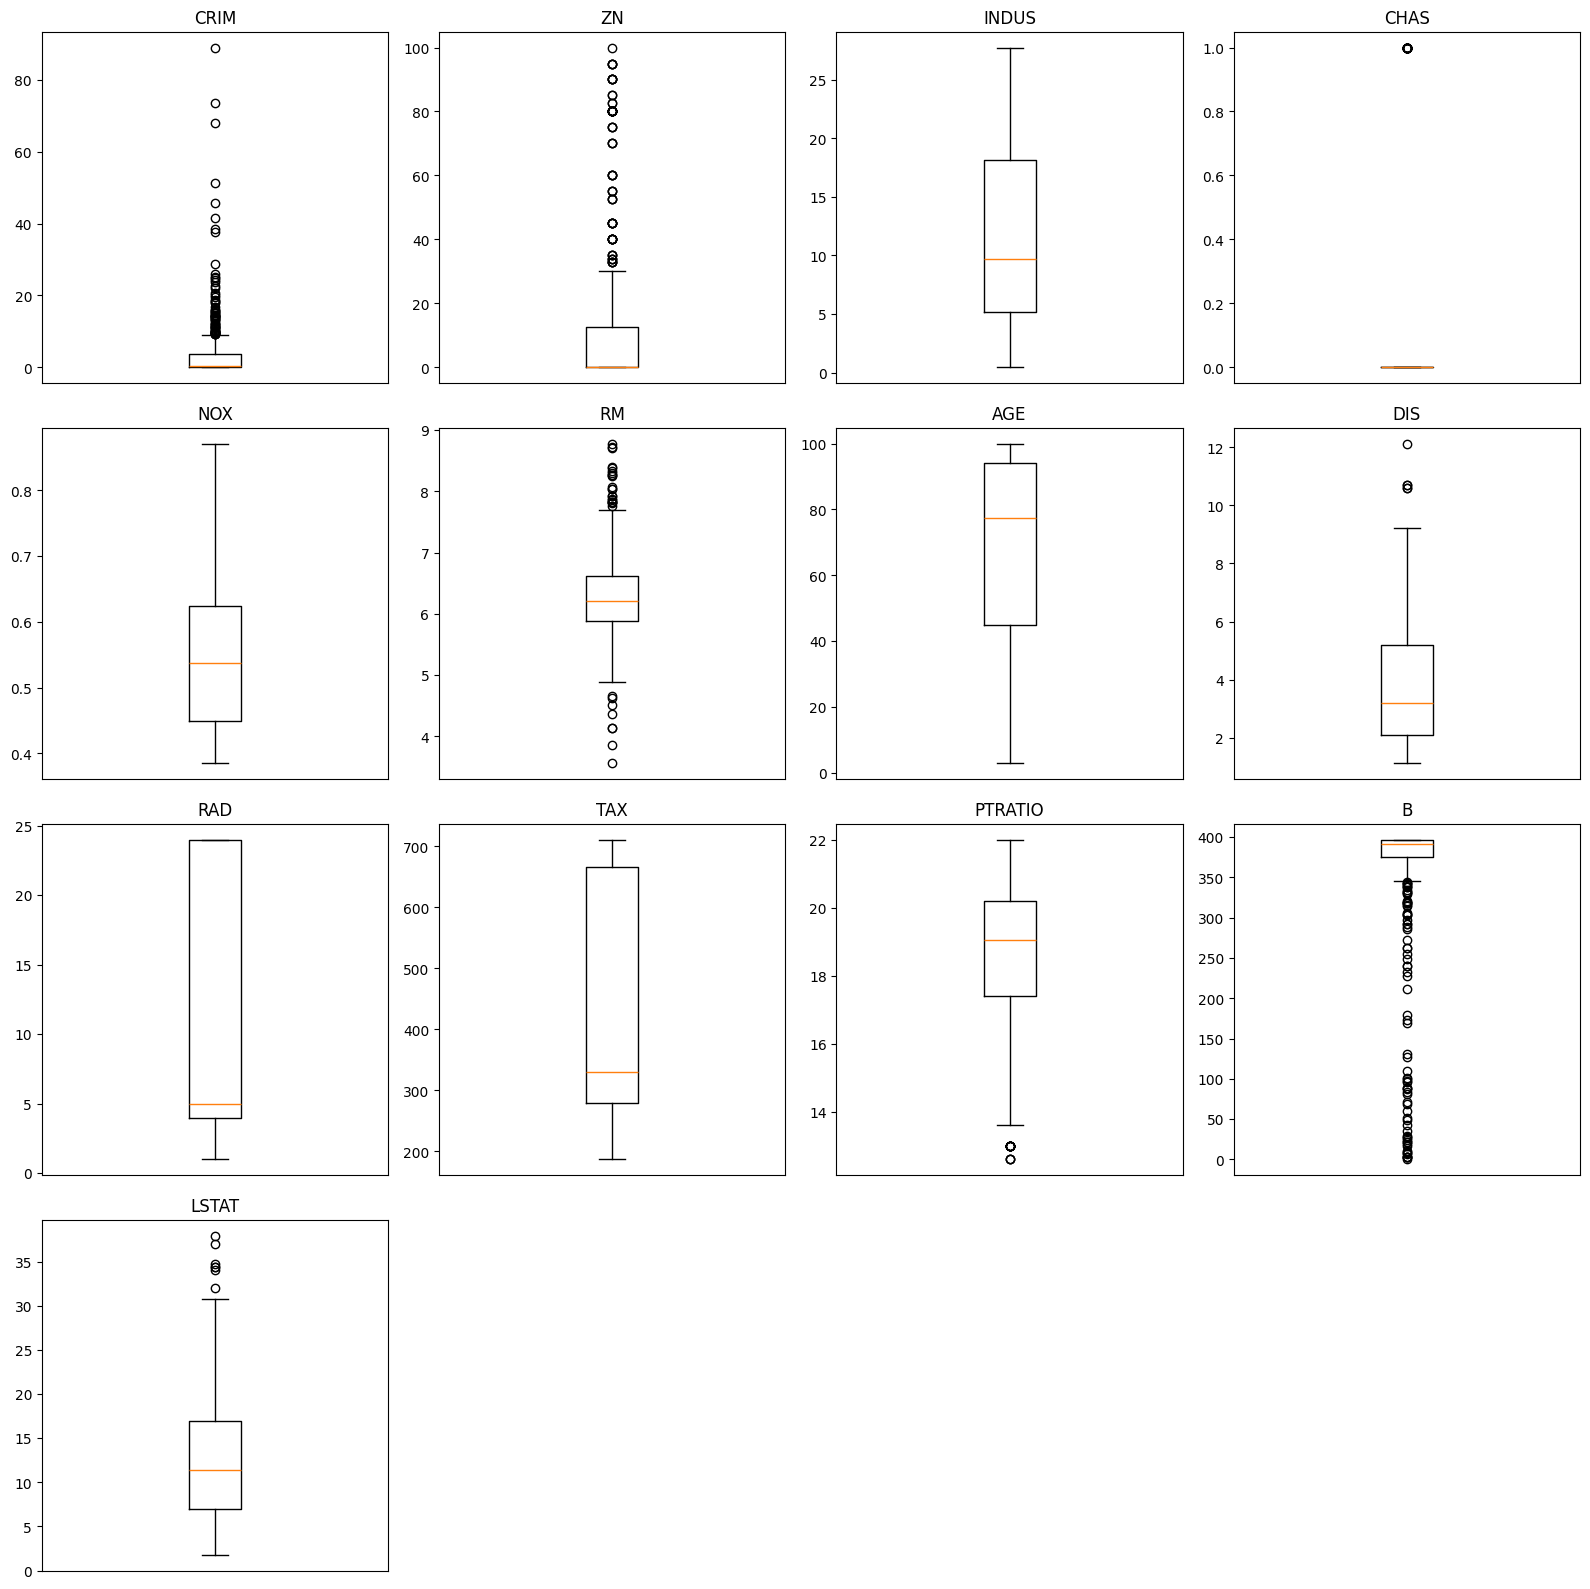

In [23]:
# Variables excluyendo MEDV
vars_box = [col for col in df.columns if col != "MEDV"]

n_vars = len(vars_box)
n_cols = 4
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(vars_box):
    axes[i].boxplot(df[var], vert=True)
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajuste fino de espacios
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.tight_layout()
plt.show()

Variables con gran cantidad de Outliers (Valores Atípicos):

-CRIM: Es la más extrema. La mayoría de los sectores tienen criminalidad casi nula, pero existen sectores con tasas altísimas que se consideran valores atípicos (los puntos superiores).

-ZN: Similar a CRIM, la mayoría de los barrios no tienen lotes grandes, pero hay un grupo específico de sectores residenciales que sí los tienen.

-B: Muestra outliers en la parte inferior. Esto indica que en la mayoría de los sectores la población es homogénea según la métrica, pero hay áreas específicas donde la proporción étnica varía drásticamente. Sin embargo el sesgo hacia abajo es parte de la naturaleza de esa fórmula social específica.

-RM: Aunque tiene una distribución más centrada, presenta valores atípicos tanto en casas con muy pocas habitaciones como en casas con muchísimas (mansiones).

Variables con Distribución Balanceada o Amplia.

-INDUS y TAX: Ambas muestran una dispersión amplia. En el caso de TAX, se nota una concentración en valores bajos y otra en valores altos, lo que sugiere sectores con cargas impositivas muy distintas.

-AGE: La caja está desplazada hacia arriba. Esto confirma que la gran mayoría de las viviendas son antiguas (el 75% supera los 45 años, como vimos en el describe).

-LSTAT: Muestra una distribución bastante saludable pero con un ligero sesgo hacia porcentajes bajos de estatus menor, con algunos puntos atípicos en el extremo superior. Tiene pocos puntos fuera de rango; un modelo robusto podría manejarlos bien.

-PTRATIO: Está concentrada en rangos altos.

Casos especiales:

CHAS como es una variable binaria (0 o 1), el boxplot se ve "aplastado". La línea naranja está en 0 porque más del 90% de los datos son 0. Los puntos en 1 son técnicamente "outliers" porque son muy pocos. Por otra parte, RAD tiene una caja pequeña pero bigotes muy largos, lo que sugiere que el acceso a carreteras radiales es similar para muchos, pero hay sectores con un índice de accesibilidad muy alto (24) que estiran el gráfico.

A ZN y CHAS no se les trata los outliers porque son variables con distribuciones muy particulares (una es binaria y la otra tiene muchos ceros). Tratarlas como outliers podría eliminar información clave.

5.- En base a los hallazgos del punto anterior, decido tratar outliers sólo en las columnas CRIM Y RM a través de windsorización.

Como los outliers de criminalidad solo están en la parte superior del boxplot. Al usar 0.05, estoy tomando ese 5% de barrios con criminalidad extrema y bajándolos al valor del percentil 95. Esto evita que el modelo crea que la delincuencia sube hasta el infinito.

Como RM tiene puntos tanto arriba como abajo de los bigotes, reparto el recorte en ambas colas para "centrar" mejor la variable.

In [24]:
from scipy.stats.mstats import winsorize

# Creo una copia para no alterar el dataframe original por error
df_cleaned = df.copy()

# 1. Winsorizo CRIM
# Aplicamo un límite del 5% en la cola superior (los valores más altos)
# limits=[0, 0.05] significa: 0% abajo, 5% arriba.
df_cleaned['CRIM'] = winsorize(df_cleaned['CRIM'], limits=[0, 0.05])

# 2. Winsorizo RM
# RM tiene outliers en ambos extremos (casas muy pequeñas y muy grandes)
# Aplicamos un límite del 2.5% en cada cola (total 5%)
df_cleaned['RM'] = winsorize(df_cleaned['RM'], limits=[0.025, 0.025])

# Verifico los cambios comparando el valor máximo original vs el nuevo
print(f"Máximo original CRIM: {df['CRIM'].max()} -> Nuevo máximo: {df_cleaned['CRIM'].max()}")
print(f"Máximo original RM: {df['RM'].max()} -> Nuevo máximo: {df_cleaned['RM'].max()}")

Máximo original CRIM: 88.9762 -> Nuevo máximo: 15.8603
Máximo original RM: 8.78 -> Nuevo máximo: 8.034


6.- Análisia univeriado de la columna principal MEDV.

6.1- Estadística descriptiva de la columna MEDV.

In [31]:
df_cleaned["MEDV"].describe()

,MEDV
count,506.000000
mean,22.532806
std,9.197104
min,5.000000
25%,17.025000
50%,21.200000
75%,25.000000
max,50.000000


-La valor promedio de la vivienda ronda los 22,533 USD (recordando que está en miles).

-Hay una desviación estándar de 9.19, lo que sugiere una variabilidad considerable.

-Los valores van desde los 5.000 hasta los 50.000 USD. El hecho de que el máximo sea exactamente 50.000 sugiere un "censurado" (es decir, todas las casas de más de 50.000 se agruparon ahí).

6.2- Análisis visual de columna MEDV: Histograma de distribución y Boxplot para detección de outliers.

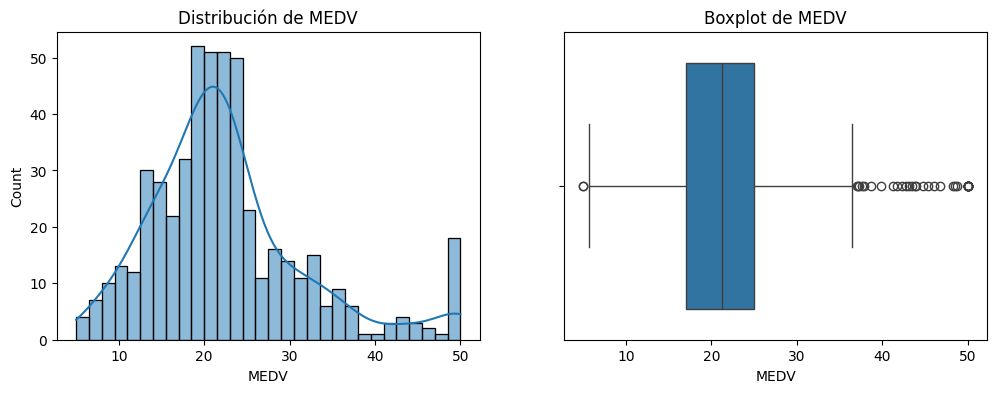

In [32]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_cleaned["MEDV"], kde=True, bins=30)
plt.title("Distribución de MEDV")

plt.subplot(1,2,2)
sns.boxplot(x=df["MEDV"])
plt.title("Boxplot de MEDV")

plt.show()

Del histograma de distribución:

La mayoría de las viviendas se concentran en el rango de los 20 a 25 (miles de USD). Hay una caída clara después de los 30. Además, la distribución tiene una "cola" hacia la derecha. Esto significa que hay menos casas caras que baratas, pero esas pocas casas caras elevan el promedio por encima de la mediana. Por último, el pequeño aumento de frecuencia justo en el valor 50. Esto confirma que en este dataset, cualquier casa que costara 50.000 o más se registró simplemente como "50". Esto crea un ruido estadístico que la regresión lineal suele notar.

Dispersión y Outliers (Boxplot)

El 50% central de los datos (la caja azul) es relativamente compacto, situándose aproximadamente entre los 17 y 25. El boxplot muestra una gran cantidad de outliers hacia la derecha (puntos después del bigote superior). Estos son los sectores de lujo o de alto valor que se alejan del comportamiento "normal" del mercado de Boston. En cuno a la asimetría, la línea central (mediana) está ligeramente desplazada hacia la izquierda dentro de la caja, lo que refuerza la idea de que los datos tienden a valores bajos/medios con casos excepcionales de alto costo.

6.3- Análisis de correlación.

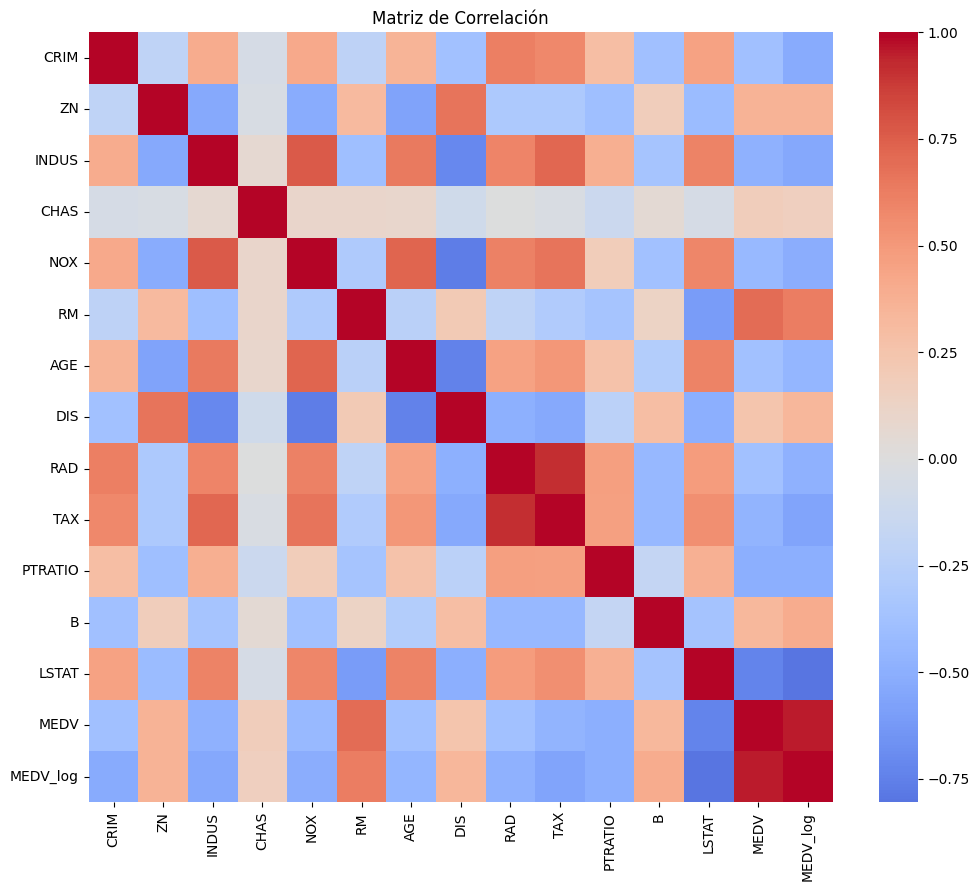

In [33]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de Correlación")
plt.show()

Mis predictores más potentes serán RM y LSTAT. Si mi modelo me diera errores de estabilidad, el primer lugar donde buscaría la causa sería es la relación entre RAD y TAX, ya que están indicando una alerta de colinealidad.

6.4- Decdo realizar transformación logarítmica a la variable principal MEDV. para "comprimir" sus outliers y hacer que la distribución sea más simétrica (forma de campana), lo cual suele mejorar mucho la precisión de las regresiones.

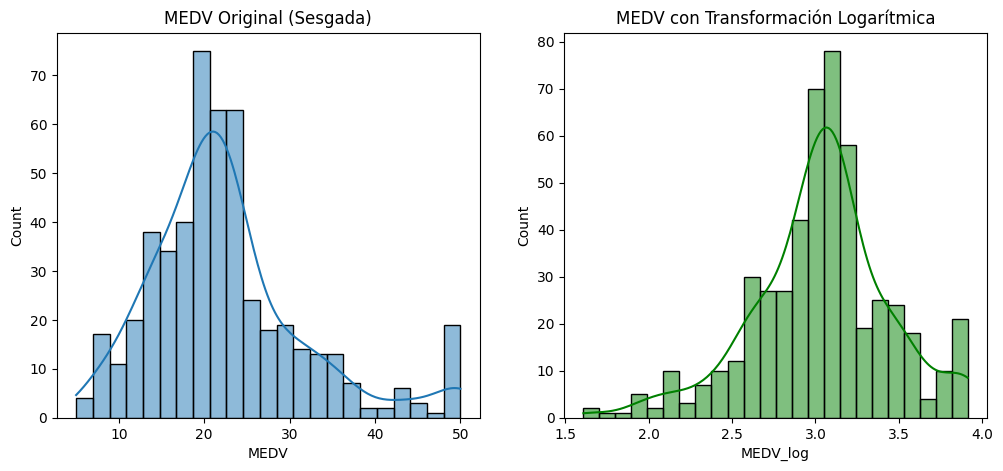

In [34]:
# 1. Aplico la transformación logarítmica
# Uso np.log1p (logaritmo de 1+x) por seguridad, aunque para MEDV np.log es suficiente
df_cleaned['MEDV_log'] = np.log(df['MEDV'])

# 2. Visualizo el efecto
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MEDV'], kde=True)
plt.title('MEDV Original (Sesgada)')

plt.subplot(1, 2, 2)
sns.histplot(df['MEDV_log'], kde=True, color='green')
plt.title('MEDV con Transformación Logarítmica')

plt.show()

Mi gráfico muestra el impacto positivo de mi decisión de aplicar la transformación logarítmica a la variable objetivo MEDV. Al comparar ambos histogramas, se logra observar cómo cambió la estructura de los datos para favorecer un modelo de regresión

7.- Del análisis exploratorio y visual. ¿Qué insights puede encontrar en la información?

Principales insights que encontré:

- Primer insight, los "Motores" del Valor Inmobiliario: El análisis de correlación y la naturaleza de los datos revelan que el precio de la vivienda en Boston no es aleatorio, sino que responde a tres pilares:

-El factor estructural: La variable RM (número de habitaciones) es el predictor positivo más fuerte. Más espacio físico se traduce directamente en mayor valor.

-El factor socioeconómico: La variable LSTAT (estatus menor), tiene la correlación negativa más alta. El entorno social pesa tanto o más que las características de la propia casa.

-El factor educativo: La proporción PTRATIO confirma que los compradores valoran la baja densidad de alumnos por profesor, penalizando el precio en zonas donde las escuelas están más saturadas.

- Segundo insight, la necesidad de refinamiento estadístico: Variables como CRIM y ZN tienen distribuciones muy sesgadas hacia valores bajos, con "picos" de criminalidad o zonas residenciales exclusivas que actúan como ruido. Además, el histograma de MEDV mostró un pico artificial en 50.0. Esto indica que el dataset tiene un "techo", y el modelo debe entender que 50 puede significar "50 o más".

- Tercer insight, la redundancia en la infraestructura: La matriz de correlación destapó que RAD (accesibilidad a carreteras) y TAX (impuestos) están casi perfectamente alineadas (0.91). Esto sugiere que la infraestructura vial de Boston está directamente ligada a la carga impositiva. Para tu modelo, usar ambas variables es redundante; podrías quedarte solo con una para simplificar la regresión sin perder capacidad predictiva.

- Cuarto insight, optimización mediante Logaritmo
La transformación logarítmica de MEDV que realizamos fue el paso definitivo para "normalizar" el mercado. Al convertir la escala a logaritmos, redujimos la influencia de las casas de lujo (outliers superiores). Esto permite que tu regresión lineal sea mucho más robusta y que sus predicciones sean más confiables para el "grueso" de la población (la clase media del dataset).

8.- Realizo modelo de regresión multiple.

Mi código para el modelo de regresión múltiple consta de 4 pasos:
1. Preparación y Limpieza Final: el formateo asegura que la variable binaria CHAS (límite con el río) sea tratada como un número entero y la separación define la matriz de predictores (X) y la variable objetivo (y), utilizando la versión logarítmica (MEDV_log) que cree para normalizar los precios.
2. Entrenamiento y Escalado: la división (Split), separa el 20% de los datos para evaluar el modelo al final (test_size=0.2), mientras que la estandarización escala las variables numéricas para que tengan media 0 y desviación estándar 1.  Excluyo a CHAS del escalado para mantener su naturaleza de "0 o 1", facilitando su interpretación posterior.
3. Selección Estratégica de Variables: El filtro teórico selecciona manualmente las 8 más importantes según el análisis previo (como las RM y LSTAT), en lugar de usar todas las columnas. Mi código elimina RAD para evitar que "choque" con TAX debido a su altísima correlación (multicolinealidad).
4. Refinamiento en Dos Pasos: El Modelo base: entrena una primera regresión con las variables elegidas teóricamente y el Modelo Final revisa los p-valores del primer modelo y crea una versión definitiva conservando únicamente las variables que son estadísticamente significativas (p < 0.05).


In [36]:
# 1. Preparación de variables
df_cleaned['CHAS'] = df_cleaned['CHAS'].astype(int)
X = df_cleaned.drop(['MEDV', 'MEDV_log'], axis=1)
y = df_cleaned['MEDV_log']

# 2. División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Escalado de datos (Manteniendo CHAS sin escalar)
scaler = StandardScaler()
cols_to_scale = X.columns.drop('CHAS')
X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# --- NUEVA SECCIÓN: SELECCIÓN TEÓRICA ---

# Definimos las variables con mayor peso teórico y eliminamos la redundancia (quitamos RAD por su alta correlación con TAX)
# Incluimos CHAS por ser la única variable geográfica directa
teoricas = ['RM', 'LSTAT', 'PTRATIO', 'DIS', 'CRIM', 'TAX', 'NOX', 'CHAS']

X_train_teorico = sm.add_constant(X_train_scaled[teoricas])

# 4. Modelado Inicial (Base Teórica)
model_teorico = sm.OLS(y_train, X_train_teorico).fit()
print("--- MODELO BASADO EN TEORÍA ---")
print(model_teorico.summary())

# 5. Refinamiento Estadístico (Solo sobre la base teórica)
# Ahora filtramos de este grupo aquellas que resultaron significativas (p < 0.05)
selected_vars = model_teorico.pvalues[model_teorico.pvalues < 0.05].index.tolist()

X_train_final = X_train_teorico[selected_vars]
model_final = sm.OLS(y_train, X_train_final).fit()

print("\n--- MODELO FINAL (TEORÍA + SIGNIFICANCIA) ---")
print(model_final.summary())

--- MODELO BASADO EN TEORÍA ---
                            OLS Regression Results                            
Dep. Variable:               MEDV_log   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     165.4
Date:                Tue, 03 Feb 2026   Prob (F-statistic):          4.87e-121
Time:                        19:51:15   Log-Likelihood:                 82.915
No. Observations:                 404   AIC:                            -147.8
Df Residuals:                     395   BIC:                            -111.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.036

Obtuve que el modelo final identifica al estatus socioeconómico (LSTAT) y al número de habitaciones (RM) como los pilares del precio, junto con un beneficio premium por la cercanía al río (CHAS). Mi modelo es robusto, explicando el 77% del mercado con variables todas significativas (p < 0.05)."

9.- Verificación de supuestos de la regresión con análisis de residuales y evaluación predictiva.

Mi último bloque de código valida y prueba mi modelo en 4 pasos:

1. Preparación de Datos de Prueba: El escalado aplica a los datos de prueba (X_test) la misma transformación estadística que usé en el entrenamiento. Esto garantiza que las unidades de medida sean coherentes para el modelo.
2. Diagnóstico de Residuales (Gráficos): Confirma que el modelo es estadísticamente válido:
•	Residuales vs. Ajustados: Verifica la homocedasticidad. Lo ideal es ver una nube de puntos aleatoria; si hay patrones (como una forma de embudo), el modelo podría estar fallando en ciertos rangos de precio.
•	Histograma y Q-Q Plot: Evalúan la normalidad. Los errores deben seguir una distribución de campana y alinearse en la diagonal del Q-Q Plot para asegurar que las pruebas de significancia ($p$-valores) sean confiables.
3. Evaluación Predictiva (Métricas): Filtra las columnas del conjunto de prueba para que coincidan exactamente con las variables seleccionadas en MI "Modelo Final". Posteriormente, cálculo de R²y RMSE mide el rendimiento en el conjunto de prueba (datos que el modelo nunca vio). Esto indica si el modelo es capaz de generalizar o si está sobreajustado (overfitting).
4. Conversión a Escala Real, el paso clave: Como entrené el modelo con el logaritmo del precio (MEDV_log), los resultados iniciales son difíciles de interpretar. Al decidir usar np.exp(), transformé el error (RMSE) de nuevo a "miles de dólares". Esto me permitiría decir, por ejemplo: "Mi modelo se equivoca, en promedio, por esta cantidad de dólares”.


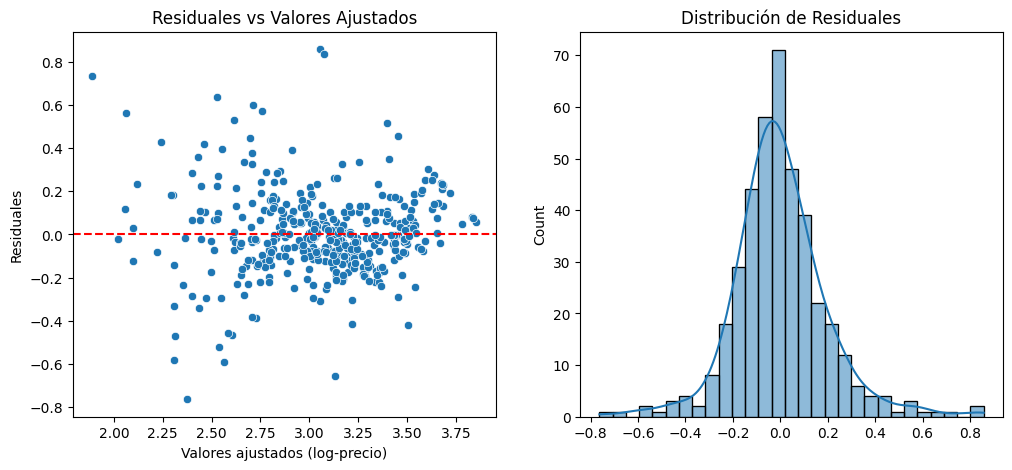

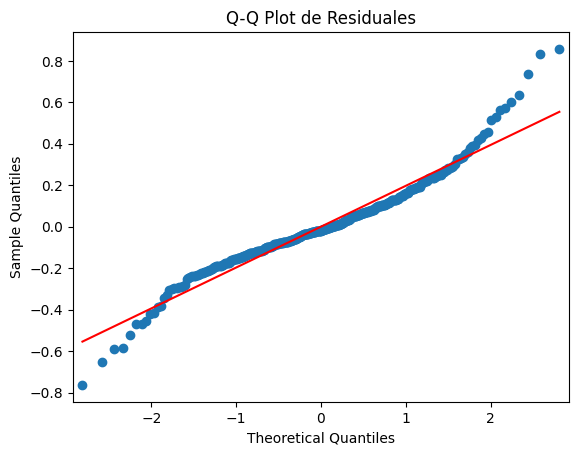

R² en Test: 0.7354
RMSE (escala log): 0.2031
RMSE en escala Real: $4.43 (miles de USD)


In [38]:
# --- PASO PREVIO: Asegurar que X_test_scaled existe ---
# (Esto debe ir justo después de definir X_test_scaled para X_train)
X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# --- 7. Diagnóstico de Residuales ---
residuals = model_final.resid
fitted = model_final.fittedvalues

plt.figure(figsize=(12, 5))

# Residuales vs Ajustados
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuales vs Valores Ajustados")
plt.xlabel("Valores ajustados (log-precio)")
plt.ylabel("Residuales")

# Histograma de Residuales
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title("Distribución de Residuales")
plt.show()

# Q-Q Plot
sm.qqplot(residuals, line="s")
plt.title("Q-Q Plot de Residuales")
plt.show()

# --- 8. Evaluación Predictiva Final ---
from sklearn.metrics import r2_score, mean_squared_error

# Seleccionamos las variables finales (incluyendo la constante si el modelo la tiene)
vars_to_use = [v for v in selected_vars if v != 'const']
X_test_final = sm.add_constant(X_test_scaled[vars_to_use])

# Predicción en escala logarítmica
y_pred_log = model_final.predict(X_test_final)

# Métricas en escala Logarítmica
r2_test = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))

print(f"R² en Test: {r2_test:.4f}")
print(f"RMSE (escala log): {rmse_log:.4f}")

# --- 9. Conversión a Escala Real (USD) ---
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"RMSE en escala Real: ${rmse_real:.2f} (miles de USD)")

- Gráfico Residuales vs. Valores Ajustados (Izquierda): No se observa un patrón claro de "embudo", lo que sugiere que la varianza de mis errores es constante. Esto es positivo, ya que indica que mi modelo es igualmente preciso para casas baratas que para casas caras en la escala logarítmica.

- Histograma de distribución de Residuales (Derecha): Los errores siguen una distribución normal. Esto valida que las pruebas estadísticas de mi modelo (como los p-valores que determinaron qué variables eran significativas) son robustas y confiables.

- Q-Q Plot de Residuales: La mayoría de los puntos siguen fielmente la línea roja diagonal. Muetsra que existe una fuerte alineación en el centro, lo que refuerza la normalidad. Sin embargo, se observa una ligera desviación en los extremos (colas).Causa: Esto suele deberse a los valores "censurados" de 50.000 USD que vimos en el análisis inicial. Es un comportamiento esperado en este dataset y no invalida mi modelo.

- Métricas:

-R² en Test de 0.7354 (73.54%): Mi modelo es capaz de explicar el 73.5% de la variabilidad de los precios en el conjunto de prueba. Es un resultado excelente. Al compararlo con el R² de entrenamiento (que fue de 0.770), veo que la diferencia es pequeña. Esto significa que no hay sobreajuste (overfitting); el modelo realmente aprendió los patrones y no solo memorizó los datos.

-RMSE (escala log) de 0.2031: Es la desviación estándar de los errores en la unidad en la que entrenaste el modelo (logaritmos).Aunque es difícil de visualizar en dinero, un valor de 0.20 en escala logarítmica es bajo, lo que indica que las predicciones están muy concentradas cerca del valor real en la curva normal que vimos en tus residuales.

-RMSE en escala Real de 4.43 (miles de USD): En promedio, las predicciones de tu modelo se desvían 4.430 (miles de USD) del precio real de la vivienda.Interpretación: Considerando que el precio promedio de las casas en este dataset es de 22,532 USD, un error de 4,430 USD es bastante aceptable. Dado que el dataset tiene valores que van desde los $5,000 hasta los $50,000, tener un error promedio de 4.4k indica que mi modelo es muy competitivo, especialmente después de haber tratado los outliers de CRIM y RM.

10.- Para Finalizar: ¿Qué nivel de ajuste tiene el modelo? ¿Cuáles son las variables que más inciden en el precio de una propiedad?

Mi modelo tiene un un nivel de ajusto alto y robusto (74-77%), es sólido. Logré reducir la complejidad eliminando variables no significativas como TAX y controlé la dispersión mediante la transformación logarítmica. Mi modelo demuestra que el precio de una propiedad en Boston depende principalmente del entorno socioeconómico (LSTAT) y del tamaño de la vivienda (RM), con un beneficio exclusivo para aquellas ubicadas junto al río (CHAS). Por otra parte, todas las variables de entorno (DIS, CRIM, NOX, PTRATIO) tienen una incidencia negativa moderada (coeficientes entre -0.07 y -0.09). Esto indica que la lejanía a centros de empleo, la delincuencia, la contaminación y la saturación escolar castigan el precio de forma similar.